In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

mpl.rcParams['font.family'] = 'serif'
cmfont = mpl.font_manager.FontProperties(fname = mpl.get_data_path() + '/fonts/ttf/cmr10.ttf')
mpl.rcParams['font.serif'] = cmfont.get_name()
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams["axes.formatter.use_mathtext"] = True

# Section 4

In [2]:
flat_source, flat_target, inv, hl, f1, L, f2, da, a_max, w = np.loadtxt('finaldata/plot4/data2mc/input.csv', delimiter = ',')
print(f"half-length = {hl}, f1 = {f1}, L = {L}, f2 = {f2}, da = {da}, a_max = {a_max}, w = {w}")

half-length = 0.001, f1 = 1.0, L = 30.0, f2 = 1.0, da = 1e-06, a_max = 75.0, w = 1.0


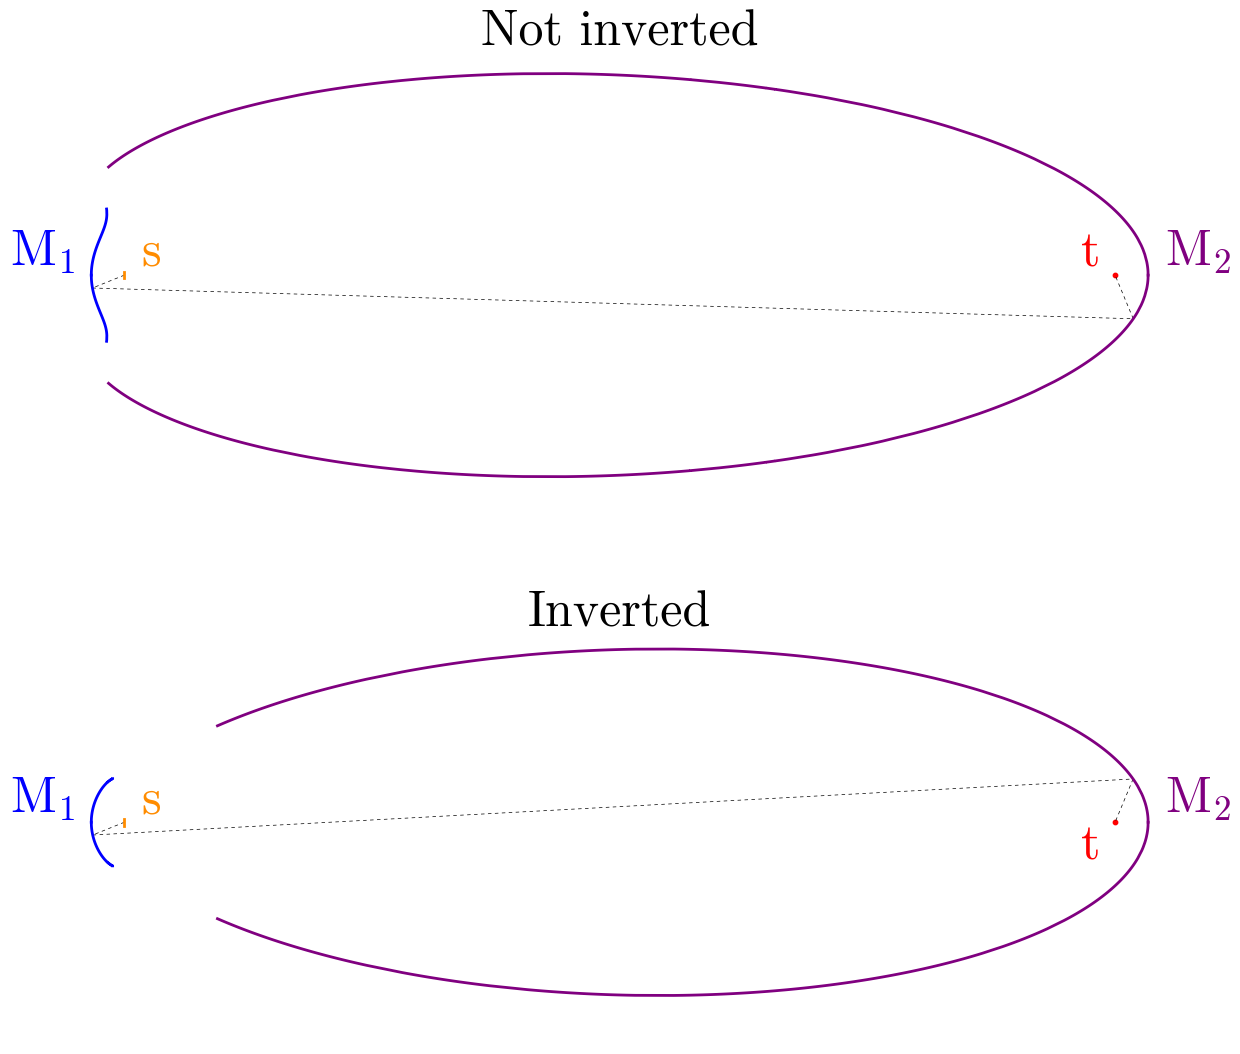

In [18]:
fig, ax = plt.subplots(2, 1, figsize = (15, 15), sharex = True, sharey = True)
plt.subplots_adjust(hspace = -0.1)
folders = ['finaldata/plot4/data2mc/', 'finaldata/plot4/data2mcinv/']

for i in range(2):
    curr_ax = ax[i]
    path = folders[i]
    curr_ax.set_axis_off()
    
    rays = np.loadtxt(f'{path}source.csv', delimiter = ',')
    for row in rays: curr_ax.plot([row[0], row[2]], [row[1], row[3]], linestyle = 'dashed', dashes = [5, 5], linewidth = 0.5, c = 'black')

    m1a = np.loadtxt(f'{path}mirror1a.csv', delimiter = ',')
    m1b = np.loadtxt(f'{path}mirror1b.csv', delimiter = ',')
    m2a = np.loadtxt(f'{path}mirror2a.csv', delimiter = ',')
    m2b = np.loadtxt(f'{path}mirror2b.csv', delimiter = ',')
    
    adj = 0.5
    curr_ax.plot(m1a[:, 0], m1a[:, 1], linewidth = 2, c = 'blue')
    curr_ax.plot(m1b[:, 0], m1b[:, 1], linewidth = 2, c = 'blue')
    curr_ax.text(-f1 - L - adj, 0, ha = 'right', va = 'bottom', s = r"$\text{M}_1$", fontsize = 36, color = 'blue')
    
    curr_ax.plot(m2a[:, 0], m2a[:, 1], linewidth = 2, c = 'purple')
    curr_ax.plot(m2b[:, 0], m2b[:, 1], linewidth = 2, c = 'purple')
    curr_ax.text(f2 + adj, 0, ha = 'left', va = 'bottom', s = r"$\text{M}_2$", fontsize = 36, color = 'purple')

    curr_ax.plot([-L, -L], [-hl * 100, hl * 100], linewidth = 2, color = 'darkorange')
    curr_ax.text(-L + adj, 0, ha = 'left', va = 'bottom', s = r"$\text{s}$", fontsize = 36, color = 'darkorange')
    curr_ax.scatter(0, 0, s = 10, c = 'red')
    curr_ax.set_aspect('equal')

ax[0].set_title("Not inverted", size = 36, y = 1)
ax[1].set_title("Inverted", size = 36, y = 0.925)
ax[0].text(0 - adj, 0, ha = 'right', va = 'bottom', s = r"$\text{t}$", fontsize = 36, color = 'red')
ax[1].text(0 - adj, 0, ha = 'right', va = 'top', s = r"$\text{t}$", fontsize = 36, color = 'red')
plt.show()

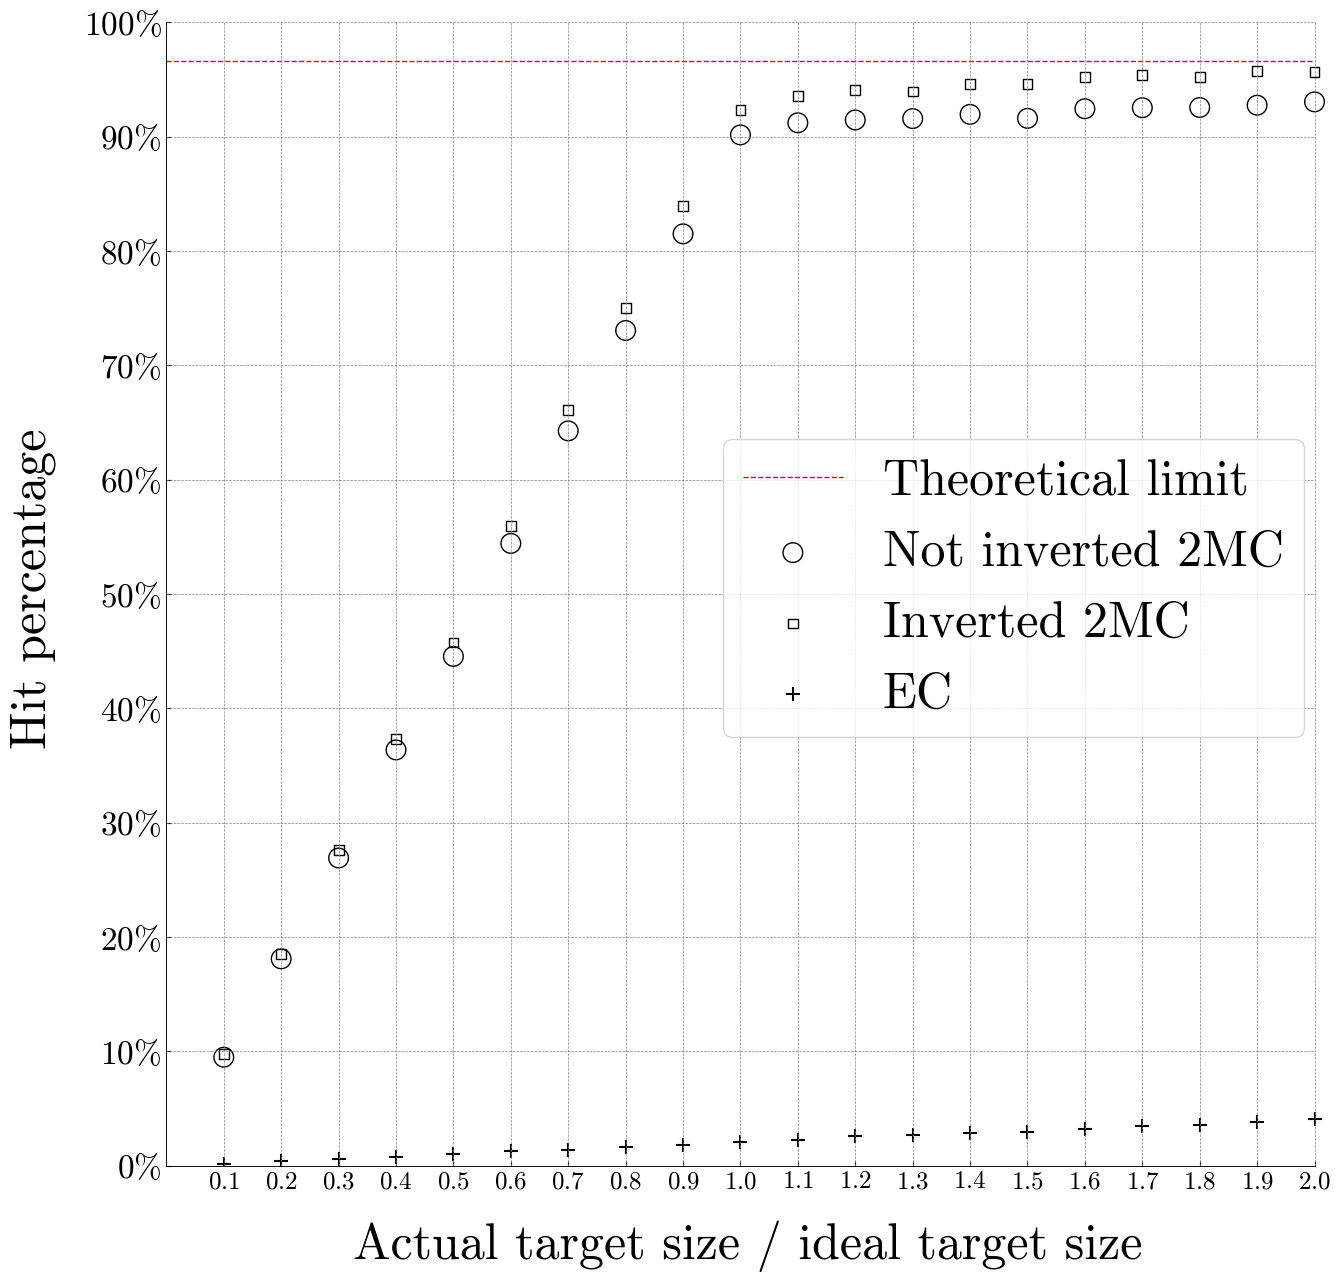

In [8]:
fig, ax = plt.subplots(1, figsize = (15, 15))
ax.locator_params(axis = 'x', nbins = 21)
ax.locator_params(axis = 'y', nbins = 11)
ax.tick_params(axis = 'x', which = 'both', direction = 'in', bottom = True, top = False, labelsize = 18)
ax.tick_params(axis = 'y', which = 'both', direction = 'in', left = True, right = False, labelsize = 24)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter(r"{x:.0f}$\%$"))

ax.spines['left'].set_position(('data', 0))
ax.spines['left'].set_bounds((0, 100))
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_bounds((0, 2))
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['right'].set_position(('data', 0))
ax.spines['right'].set_bounds((0, 100))
ax.spines['right'].set_linewidth(0.5)
ax.spines['top'].set_position(('data', 0))
ax.spines['top'].set_bounds((0, 2))
ax.spines['top'].set_linewidth(0.5)

B_max = np.sin(np.deg2rad(a_max))
ax.plot([0, 2], [B_max * 100, B_max * 100], zorder = 0, linestyle = 'dashed', linewidth = 1, color = 'red', label = "Theoretical limit")

hit2mc = np.loadtxt('finaldata/plot4/data2mc/hits.csv', delimiter = ',')
ax.scatter(hit2mc[:, 0], hit2mc[:, 1] * 100, marker = 'o', s = 200, facecolors = 'none', edgecolors = (0, 0, 0), label = "Not inverted 2MC")
hit2mcinv = np.loadtxt('finaldata/plot4/data2mcinv/hits.csv', delimiter = ',')
ax.scatter(hit2mcinv[:, 0], hit2mcinv[:, 1] * 100, marker = 's', s = 50, facecolors = 'none', color = (0, 0, 0), label = "Inverted 2MC")
hitell = np.loadtxt('finaldata/plot4/dataell/hits.csv', delimiter = ',')
ax.scatter(hitell[:, 0], hitell[:, 1] * 100, marker = '+', s = 100, color = (0, 0, 0), label = "EC")

ax.hlines(y = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100], xmin = 0, xmax = 2, linestyle = 'dashed', linewidth = 0.5, color = 'grey')
ax.vlines(x = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0], ymin = 0, ymax = 100, linestyle = 'dashed', linewidth = 0.5, color = 'grey')
ax.set_xlim(0, 2.025)
ax.set_ylim(0, 101)
ax.get_xticklabels()[0].set_visible(False)
ax.set_xlabel("Actual target size / ideal target size", size = 36, labelpad = 20)
ax.set_ylabel("Hit percentage", size = 36, labelpad = 20)
ax.legend(loc = "center right", fontsize = 36)
plt.show()